Code for the main model in

Froudist-Walsh, Sean, Daniel P. Bliss, Xingyu Ding, Lucija Jankovic-Rapan, Meiqi Niu, Kenneth Knoblauch, Karl Zilles, Henry Kennedy, Nicola Palomero-Gallagher, and Xiao-Jing Wang. "A dopamine gradient controls access to distributed working memory in monkey cortex." Neuron (2021).

Sean Froudist-Walsh


In [1]:
# let's get what we need together
from __future__ import division
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt


%matplotlib inline
import pandas
import scipy.io as sio
import brian2
import os
import copy
import pickle

import json
import copy
import shutil
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
from joblib import Parallel, delayed



In [2]:
scaler = 1 #default
# scaler = 0.5
PARAMS = {
    # local connectivity strengths
          # local strengths E-->
          'g_e_self': 0.18 * brian2.nA,
          'g_e_cross': 0 * brian2.nA,
          'g_pv_e' : 0.174   * brian2.nA,
          'g_sst_e_self' : 0.0435   * brian2.nA,
          'g_sst_e_cross' : 0.0435   * brian2.nA,
          'g_vip_e' : 0.058   * brian2.nA,
          # local strengths PV-->
          'g_e_pv_min': -0.001 * brian2.nA, # dopamine dependent min PV->E strength
          'g_e_pv_max': -0.4 * brian2.nA, # dopamine dependent max PV->E strength #<------------------------
          'g_pv_self': -0.18 * brian2.nA,
          # local strengths SST-->
          'g_e_sst_min': -0.09 * brian2.nA, # dopamine dependent min SST->E strength #<--------------------------
          'g_e_sst_max': -0.11 * brian2.nA, # dopamine dependent max SST->E strength
          'g_pv_sst': -0.17 * brian2.nA,
          'g_vip_sst': -0.1 * brian2.nA,
          # local strengths VIP-->
          'g_sst_vip': -0.05 * brian2.nA,

    # Time constants
          'tau_nmda': 60 * brian2.ms,
          'tau_ampa': 2 * brian2.ms,
          'tau_gaba': 5 * brian2.ms,
          'tau_gaba_dend': 10 * brian2.ms,
          'tau_adapt': 0.1   * brian2.second,

    # synaptic rise constants
          'gamma_nmda': 1.282, # unitless
          'gamma_gaba': 2,
          'gamma_ampa': 5,

    # AMPA/(AMPA+NMDA) fraction
          'ampa_frac_pv': 0.2, # AMPA fraction (1-NMDA fraction) for PV cells
          'ampa_frac': 0.1,    # AMPA fraction (1-NMDA fraction) for all other cell types




    # background inputs

          # 'I_background_e': 310 * brian2.pA, #default
          'I_background_e': 155 * brian2.pA,
          # 'I_background_i': 300 * brian2.pA, #default
          'I_background_i': 260 * brian2.pA,
          'I_background_dend': 30 * brian2.pA, #default


          # 'I_background_e': (310 * scaler) * brian2.pA,
          # 'I_background_i': (300 * scaler) * brian2.pA,
    # dendrite I/O function parameters
          'c1': 120 * brian2.pA,
          'c2': 136.24 * brian2.pA,
          'c3': 7.0,
          'c4': 0 * brian2.pA,
          'c5': 9.64 * brian2.pA,
          'c6': 20 * brian2.pA,

    # adaptation strengths
          'g_adapt_e': -0.004 * brian2.nA,
          'g_adapt_sst': -0.004 * brian2.nA,
          'g_adapt_vip': -0.004 * brian2.nA,

    # f-I curve parameters - E populations
          'a_e': 0.135 * brian2.Hz / brian2.pA,
          'b_e': 54 * brian2.Hz,
          'd_e': 0.308 * brian2.second,

    # f-I curve parameters - I populations
          'c_I_sst': 132 * brian2.Hz / brian2.nA,
          'c_I_vip': 132 * brian2.Hz / brian2.nA,
          'c_I_pv': 330 * brian2.Hz / brian2.nA,
          'r_0_sst': -33 * brian2.Hz,
          'r_0_vip': -33 * brian2.Hz,
          'r_0_pv': -95 * brian2.Hz,


    # rescale FLN parameter
          'b1': 0.3, #default
          # 'b1': 0.25,

    # Long-range E targets
    #       'lr_e_self_dend': 0.9, #concern
          'lr_e_self_dend': 1.0,
          # 'lr_e_cross_dend': 0.1,

    # Long-range I targets
          'lr_pv_e': 0.31,
          'lr_sst_e_self': 0.22 ,
          'lr_vip_e_self': 0.47,

    # Long-range I targets in FEF
          'lr_pv_e_fef': 0.2,
          'lr_sst_e_self_fef': 0.1 ,
          'lr_vip_e_self_fef': 0.7,

    # parameters for D1 occupancy
          'slope_d1occ' : 2,
          'midpoint_d1occ' : 1,

    # parameters for DA modulation of NMDA
          'slope_nmda_da' : 10,
          'midpoint_nmda_da' : 0.35,
          'g_nmda_da': 0.6,

    # parameters for m current
          'slope_m' : 14,
          'midpoint_m' : 0.85,
          'g_m' : -0.5  * brian2.nA,


    # Simulation parameters
        # initial firing rates
        #   'r_0_e': 5 * brian2.Hz, #default
          'r_0_e': 0 * brian2.Hz,
        # timestep
          'dt': 0.5 * brian2.ms, #default
          # 'dt': 5.0 * brian2.ms,
        # trial length


         # target stimulus on time
          'stim_on': 1 * brian2.second,
        # target stimulus off time
          'stim_off': 1.4 * brian2.second,
          # 'stim_off': 3.4 * brian2.second,

        # target stimulus on time
        #   'stim_on': 0.1 * brian2.second,
        # # target stimulus off time
        #   'stim_off': 0.4 * brian2.second,
        #
        #   'stim_on2': 0.8 * brian2.second,
        # # target stimulus off time
        #   'stim_off2': 1.1 * brian2.second,
        #
        #   'stim_on3': 1.5 * brian2.second,
        # # target stimulus off time
        #   'stim_off3': 1.8 * brian2.second,

        # distractor stimulus on time (if using)
          'distract_on': 2 * brian2.second,
        # distractor stimulus off time (if using)
          'distract_off': 2.4 * brian2.second,


    # stimulus strength
    #       'stim_strength': 0.1 * brian2.nA, #default
          'stim_strength': 0.0 * brian2.nA,


    # dopamine release level for the current simulation
    #     'da_rel': 1.5, #default
          'da_rel': 0.5,

          'std_noise': 4 * brian2.pA,
          # 'std_noise': 0.0 * brian2.pA,

          'trial_length': 5 * brian2.second,
        # Long-range connectivity strengths
          'mu_ee': 1.45, #default
              # 'mu_ie': 2.24, #default
          # 'mu_ee': 1.5,
          'mu_ie': 1.8,

# Min excitatory gradient (spine count) value
    #       'e_grad_min': 0.45, #default
          'e_grad_min': 0.15 #acceptable ranges from 0.1-0.2

}

with open('large_scale_visualWM_DA_params.pck', 'wb') as f:
    pickle.dump(PARAMS, f)

Equations 38 & 39 of the manuscript.

Define the function that transforms input current to changes in firing rate for excitatory neurons (Abbott and Chance, 2005).
<br>
$$r_E = \frac{aI_{total,E} - b}{1 - e^{-d(aI_{total,E} - b)}} $$

Update the firing rates of the interneurons using a threshold linear input/output function
$$ \begin{cases}
  r_I = c_II_{total,I} + r_0 & \text{for } I_{total,I}\ge -r_0/c_I\\
  r_I = 0     & \text{otherwise }
\end{cases} $$


In [3]:
def current_to_frequency(input_current,population_type,parameters):
    if population_type == 'E':
        a = parameters['a_e']
        b = parameters['b_e']
        d = parameters['d_e']
        return np.divide((a*input_current - b),(1 - np.exp(-d*(a*input_current - b))))
    if population_type == 'PV':
        c_I = parameters['c_I_pv']
        r_0 = parameters['r_0_pv']
        r = np.maximum(c_I*input_current + r_0,0)
        return r
    if population_type == 'SST':
        c_I = parameters['c_I_sst']
        r_0 = parameters['r_0_sst']
        r = np.maximum(c_I*input_current + r_0,0)
        return r
    if population_type == 'VIP':
        c_I = parameters['c_I_vip']
        r_0 = parameters['r_0_vip']
        r = np.maximum(c_I*input_current + r_0,0)
        return r


Equation 36.

Define the current formulation of the dendrite input-output function (presuming $I_{inh}$ is negative)
<br>
<br>
$$
I_{soma,dendrite} = f_I(I_{exc},I_{inh}) =
c_1.\biggl[\tanh\biggl(\dfrac{I_{exc} + c_3*I_{inh} + c_4}{c_5 e^{-I_{inh}/c6}}\biggr)\biggr] + c_2
$$

In [4]:
def dendrite_input_output(exc_current,inh_current,parameters):
    c1 = parameters['c1']
    c2 = parameters['c2']
    c3 = parameters['c3']
    c4 = parameters['c4']
    c5 = parameters['c5']
    c6 = parameters['c6']

    beta = c5*np.exp(-inh_current/c6)

    return c1*(np.tanh((exc_current +c3*inh_current + c4)/beta)) + c2

Equation 14.

Define the NMDA derivative
<br>
$$ \frac{dS_{NMDA}}{dt} = -\frac{S_{NMDA}}{\tau_{NMDA}} + (1 - S_{NMDA})\gamma r_E$$
(Wong & Wang, 2006)

In [5]:
def NMDA_deriv(S_NMDA_prev,rate_now,parameters):

    return -S_NMDA_prev/parameters['tau_nmda'] + parameters['gamma_nmda']*(1 - S_NMDA_prev)*rate_now

Equation 15.

Define the AMPA derivative
<br>
$$ \frac{dS_{AMPA}}{dt} = -\frac{S_{AMPA}}{\tau_{AMPA}} + \gamma_{AMPA}r_E$$
(Wong & Wang, 2006)

In [6]:
def AMPA_deriv(S_AMPA_prev,rate_now,parameters):

    return -S_AMPA_prev/parameters['tau_ampa'] + parameters['gamma_ampa']*rate_now

Equations 16/17.

Define the GABA derivative
<br>
$$ \frac{dS_{GABA}}{dt} = -\frac{S_{GABA}}{\tau_{GABA}} + \gamma_Ir_I$$
(Wong & Wang, 2006)

In [7]:
def GABA_deriv(S_GABA_prev,rate_now,parameters,cell_section):
    if cell_section == 'soma':
        return -S_GABA_prev/parameters['tau_gaba'] + parameters['gamma_gaba']*rate_now
    elif cell_section == 'dendrite':
        return -S_GABA_prev/parameters['tau_gaba_dend'] + parameters['gamma_gaba']*rate_now

Equation 18.

Define the adaptation current derivative
$$ \frac{dS_{a}}{dt} = -\frac{S_{a}}{\tau_{a}} + r $$
(Engel & Wang, 2001)

In [8]:
def adaptation_deriv(S_a_prev,rate_now,parameters):
    return -S_a_prev/parameters['tau_adapt'] + rate_now

Equations 8, 11, 13.

Several of dopamine's effects are modeled with a sigmoid function (such as how release gets converted to fraction of occupied D1 receptors).

$$ \frac{e^{b(h-c)}}{1 + e^{b(h-c)}} $$

In [9]:
def sigmoid_DA(height,midpoint,slope):
     return np.exp(slope*(height-midpoint))/(1 + np.exp(slope*(height-midpoint)))


Model parameters. Corresponds to Table S6 of the manuscript.

In [10]:
# with open('large_scale_visualWM_DA_params.pck') as f:
#     PARAMS_2 = pickle.load(f)


# print(PARAMS_2['stim_strength'])

Load in anatomical data

In [11]:
def load_anatomy():
    # Load in anatomical data file
    subgraph_data = sio.loadmat('anatomical_data/beta_bin_hierarchy_subgraph.mat')
    sln = subgraph_data['HierOrderedSLNsubgraph']
    fln = subgraph_data['HierOrderedFLNsubgraph']
    hierarchy = subgraph_data['hierarchy_vals_subgraph']


    temp_list = subgraph_data['subgraph_hierarchical_order']
    area_list_SLN = []
    for row in temp_list:
        v = '%s' % str(row[0][0])
        area_list_SLN.append(v)

    area_column_list  = ['from '+ mystring for mystring in area_list_SLN]
    area_row_list  = ['to '+ mystring for mystring in area_list_SLN]

    df_fln = pandas.DataFrame(fln , columns=area_column_list, index=area_row_list)

    df_sln = pandas.DataFrame(sln , columns=area_column_list, index=area_row_list)

    # load the receptor data
    D1R_data = sio.loadmat('anatomical_data/D1R_lyon_regions.mat')

    D1_density_raw = D1R_data['D1R_lyon_regions_40']

    # load the spine count data
    spine_data = sio.loadmat('anatomical_data/spine_count_lyon_regions.mat')

    spine_count_raw = spine_data['spine_count_lyon_regions_40']

    df_raw_anatomy = pandas.DataFrame(D1_density_raw, columns=['D1R'], index=area_list_SLN)
    df_raw_anatomy.loc[:,'spines'] = spine_count_raw
    df_raw_anatomy.loc[:,'hierarchy'] = hierarchy

    
    return (sln, fln, hierarchy, area_list_SLN,
        df_fln, df_sln, D1_density_raw, spine_count_raw, df_raw_anatomy)


In [12]:
def prepare_connectivity(parameters,spine_count_raw,fln,sln,d1_density_raw):

    d1_occ = sigmoid_DA(parameters['da_rel'],parameters['midpoint_d1occ'],parameters['slope_d1occ'])

    ######## Excitatory gradient ########
    # scale spine count to lie within [0,1] range
    min_spine_count = np.min(spine_count_raw)
    spine_count_rescaled = spine_count_raw-min_spine_count
    spine_grad = spine_count_rescaled/np.max(spine_count_rescaled)

    # define the excitatory gradient to lie according to the spine count 
    e_grad_scaling_factor = 1 - parameters['e_grad_min'] 
    e_grad = parameters['e_grad_min'] + e_grad_scaling_factor*spine_grad


    ######## Local connectivity ########
    # set up the local connectivity matrix
    J =  np.array([#soma dend pv sst vip
        [parameters['g_e_self'] , 0, parameters['g_pv_e'], parameters['g_sst_e_self'],parameters['g_vip_e']],

                [0,0,0,0,0],

                  [parameters['g_e_pv_min'],0,parameters['g_pv_self'], 0, 0],

                  [0,0,parameters['g_pv_sst'], 0,parameters['g_vip_sst']],


                  [0,0,0,parameters['g_sst_vip'],0],

                  ]).T * brian2.amp


    pops = ['E1soma','E1dend','PV','SST1','VIP1']
    pops_column_list  = ['from '+ mystring for mystring in pops]
    pops_row_list  = ['to '+ mystring for mystring in pops]

    J_display = J*(1/brian2.pA)
    df_J = pandas.DataFrame(J_display, columns=pops_column_list, index=pops_row_list)
    df_J

    ######### numbers of areas, populations ##########

    num_pops  = J.shape[0]
    num_e_pops = 1
    num_areas = fln.shape[0]

    ######### adaptation ###########
    g_adapt = np.array([parameters['g_adapt_e'],
                        0,
                        0,
                        parameters['g_adapt_sst'],
                        parameters['g_adapt_vip']])* brian2.amp

    
    g_m = np.array([parameters['g_m'],0,0,0,0])* brian2.amp
    
    ######### AMPA/(AMPA+NMDA) fraction ##########

    ampa_frac = np.array([parameters['ampa_frac'],
                          parameters['ampa_frac'],
                          parameters['ampa_frac_pv'],
                          parameters['ampa_frac'],
                          parameters['ampa_frac']])
    nmda_frac = 1 - ampa_frac

    J_nmda = J*((J>0).astype(int))
    J_ampa = J*((J>0).astype(int))
    J_gaba = J*((J<0).astype(int))

    J_gaba_dend =  np.array([[0,
                              0,
                              0,
                              parameters['g_e_sst_min'],
                              0],

                             ]) * brian2.amp

    ####### LONG-RANGE CONNECTIONS ########
    # Compress FLN
    fln_squish = np.power(fln,parameters['b1'])
    fln_rowtotal = np.sum(fln_squish,axis=1)
    fln_rowtotal_mat = np.matlib.repmat(fln_rowtotal, num_areas,1).T
    fln_squishnorm = fln_squish/fln_rowtotal_mat

    # Isolate long-range connections from superficial layers
    W_superficial = fln_squishnorm*sln
    # Isolate long-range connections from deep layers
    W_deep = fln_squishnorm*(1-sln)


    # This matrix splits the long-range current onto each local population of cells
    lr_targets = np.array([[0,
                            parameters['lr_e_self_dend'],
                            parameters['lr_pv_e'],
                            parameters['lr_sst_e_self'],
                            parameters['lr_vip_e_self']],
                           ]).T * brian2.nA
    
    # This matrix splits the long-range current onto each local population of cells - reflecting greater proportion of CR cells in FEF (Pouget et al., 2009)
    lr_targets_FEF = np.array([[0,
                                parameters['lr_e_self_dend'],
                                parameters['lr_pv_e_fef'],
                                parameters['lr_sst_e_self_fef'],
                                parameters['lr_vip_e_self_fef']],


                                ]).T * brian2.nA

    ##### Dopamine modulation #####
    # scale_receptors to lie within [0,1] range
    min_d1R = np.min(d1_density_raw)
    d1R_rescaled = np.squeeze(d1_density_raw)-min_d1R
    d1_grad = d1R_rescaled/np.max(d1R_rescaled)

    # strength of excitatory currents through NMDA receptors increases with dopamine (Seamans et al., PNAS, 2001)
    # To remove effect of dopamine on NMDA, while keeping other dopamine effects, set d1_occ here = 0
    nmda_da_grad = 1 + parameters['g_nmda_da']*sigmoid_DA(d1_occ*np.expand_dims(d1_grad,axis=1),parameters['midpoint_nmda_da'],parameters['slope_nmda_da'])

    # PV-->soma strength decreases with dopamine (Gao et al., J Neurosci, 2003)
    # To remove effect of dopamine on PV-->E connections, while keeping other dopamine effects, set d1_occ here = 0
    e_pv_da_grad = (parameters['g_e_pv_max'] + d1_occ*d1_grad*(parameters['g_e_pv_min'] - parameters['g_e_pv_max']))/parameters['g_e_pv_min']

    e_pv_da_mat = np.concatenate((np.expand_dims(e_pv_da_grad,axis=1),np.ones((num_areas,num_pops-num_e_pops))),axis=1)

    # SST-->dendrite strength increases with dopamine (Gao et al., J Neurosci, 2003)
    # To remove effect of dopamine on PV-->E connections, while keeping other dopamine effects, set d1_occ here = 0
    e_sst_da_grad = (parameters['g_e_sst_min'] + d1_occ*d1_grad*(parameters['g_e_sst_max'] - parameters['g_e_sst_min']))/parameters['g_e_sst_min']

    # e_sst_da_mat = np.concatenate((np.expand_dims(e_sst_da_grad,axis=1)))
    e_sst_da_mat = e_sst_da_grad[:, None]
    # High levels of D1 receptor stimulation engage an outward M-channel, reducing excitability (Arnsten et al., Neurobio. Stress., 2019)
    # To remove effect of dopamine on the M-channel, while keeping other dopamine effects, set d1_occ here = 0
    m_da_grad = sigmoid_DA(d1_occ*d1_grad,parameters['midpoint_m'],parameters['slope_m']).reshape(num_areas,1)

    return(pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac, J_nmda, J_ampa, 
          J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets, nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad,g_m,lr_targets_FEF)


Set up model

In [13]:
def initialise_variables(PARAMS,num_areas,num_pops,num_e_pops,area_list_SLN):

    # Initialise
    num_iterations = int(PARAMS['trial_length']/PARAMS['dt'])

    # Choose initial values for rates and synapse variables
    R0 = np.matlib.repmat(np.array([PARAMS['r_0_e'],0,PARAMS['r_0_e'],PARAMS['r_0_e'],PARAMS['r_0_e']]), num_areas, 1) * brian2.Hz
    R = np.zeros((num_iterations,num_areas,num_pops)) * brian2.Hz
    R[0,:,:] = R0

    s_nmda = np.zeros((num_iterations,num_areas,num_pops))
    s_ampa = np.zeros((num_iterations,num_areas,num_pops))
    s_gaba = np.zeros((num_iterations,num_areas,num_pops))
    s_gaba_dend = np.zeros((num_iterations,num_areas,num_pops))
    s_gaba_dend[0,:,:] = 1
    s_gaba[0,:,:] = 1
    s_adapt = np.zeros((num_iterations,num_areas,num_pops))

    # # Preassign external inputs
    I_ext    = np.zeros((num_iterations,num_areas,num_pops)) * brian2.amp

    # Let's apply external stimulation to V1 populations E1 & E2
    I_ext[int(PARAMS['stim_on']/PARAMS['dt']):int(PARAMS['stim_off']/PARAMS['dt']),area_list_SLN.index('V1'),pops.index('E1dend')] = PARAMS['stim_strength']
    # I_ext[int(PARAMS['stim_on']/PARAMS['dt']):int(PARAMS['stim_off']/PARAMS['dt']),area_list_SLN.index('32'),pops.index('E1dend')] = PARAMS['stim_strength']


    # I_ext[int(PARAMS['stim_on2']/PARAMS['dt']):int(PARAMS['stim_off2']/PARAMS['dt']),area_list_SLN.index('V1'),pops.index('E1dend')] = PARAMS['stim_strength']
    # I_ext[int(PARAMS['stim_on3']/PARAMS['dt']):int(PARAMS['stim_off3']/PARAMS['dt']),area_list_SLN.index('V1'),pops.index('E1dend')] = PARAMS['stim_strength']



    # No distractor
#     I_ext[int(PARAMS['distract_on']/PARAMS['dt']):int(PARAMS['distract_off']/PARAMS['dt']),area_list_SLN.index('V1'),pops.index('E2dend')] = PARAMS['stim_strength']

    # Create matrices in which we can store the currents
    I_lr_nmda    =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_lr_ampa    =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_local_nmda =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_local_ampa =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_local_gaba =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_soma_dend  =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_total      =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_total_abs  =  np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA
    I_exc_dend   = np.zeros((num_iterations,num_areas,num_e_pops)) * brian2.pA
    I_inh_dend   = np.zeros((num_iterations,num_areas,num_e_pops)) * brian2.pA
    I_local_gaba_dend =  np.zeros((num_iterations,num_areas,num_e_pops)) * brian2.pA
    I_adapt = np.zeros((num_iterations,num_areas,num_pops)) * brian2.pA

    # Define background inputs
    I_0 = np.zeros((num_areas,num_pops)) * brian2.pA
    I_0[:,[pops.index('E1soma')]] = PARAMS['I_background_e']
    I_0[:,[pops.index('E1dend')]] = PARAMS['I_background_dend']
    I_0[:,[pops.index('PV'),pops.index('SST1'),pops.index('VIP1')]] = PARAMS['I_background_i']

    # Let's set up the noise. We will model the noise as an Ornstein-Uhlenbeck process.
    # Gaussian noise. mean 0, std 1. Dims: timesteps, local populations, areas
    eta = np.random.normal(loc=0.0, scale=1.0, size=(num_iterations,num_areas,num_pops))
    # eta[:,:,1:] = 0 #remove noise from non-soma

    # prepare the right hand side of the above equation
    noise_rhs = eta*((np.sqrt(PARAMS['tau_ampa']*np.power(PARAMS['std_noise'],2))*np.sqrt(PARAMS['dt']))/PARAMS['tau_ampa'])
    noise_rhs[:,:,1:2] = 0 # remove noise from dendrites
    I_noise = np.zeros((num_areas , num_pops )) *brian2.pA

    return(num_iterations,R,s_nmda,s_ampa,s_gaba,s_gaba_dend,s_adapt
           ,I_ext,I_lr_nmda,I_lr_ampa,I_local_nmda,I_local_ampa,I_local_gaba
           ,I_soma_dend,I_total,I_exc_dend,I_inh_dend,I_local_gaba_dend,I_adapt
           ,I_0,I_noise,noise_rhs,I_total_abs)
        


In [14]:
 def large_scale_da_model(pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac
                          , J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets
                          , nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad,num_iterations,R,s_nmda
                          ,s_ampa,s_gaba,s_gaba_dend,s_adapt
                          ,I_ext,I_lr_nmda,I_lr_ampa,I_local_nmda,I_local_ampa,I_local_gaba
                          ,I_soma_dend,I_total,I_exc_dend,I_inh_dend,I_local_gaba_dend,I_adapt
                          ,I_0,I_noise,noise_rhs,parameters,lr_targets_FEF,I_total_abs):
    for i_t in range(1,num_iterations):

        # update noise - dims = num local pops x num areas
        I_noise = I_noise + -I_noise*(parameters['dt']/parameters['tau_ampa']) + noise_rhs[i_t-1,:,:]

        # Long range NMDA to E populations
        I_lr_nmda[i_t-1,:,:2]   = ((e_grad*parameters['mu_ee']*nmda_da_grad)*W_superficial).dot(s_nmda[i_t-1,:,:1]).dot(nmda_frac[:2]*lr_targets[:2,:].T)
        # Long range NMDA to I populations 
        I_lr_nmda[i_t-1,:,2:]   = parameters['mu_ie']*e_grad*nmda_da_grad*(W_deep.dot(s_nmda[i_t-1,:,:1])).dot(nmda_frac[2:]*lr_targets[2:,:].T)
        # Long range NMDA to I populations in FEF
        I_lr_nmda[i_t-1,[area_list_SLN.index('8m'),area_list_SLN.index('8l')],2:]   = parameters['mu_ie']*e_grad[[area_list_SLN.index('8m'),area_list_SLN.index('8l')]]*nmda_da_grad[[area_list_SLN.index('8m'),area_list_SLN.index('8l')]]*(W_deep[[area_list_SLN.index('8m'),area_list_SLN.index('8l')],:].dot(s_nmda[i_t-1,:,:1])).dot(nmda_frac[2:]*lr_targets_FEF[2:,:].T)

        
        # Long range AMPA to E populations 
        I_lr_ampa[i_t-1,:,:2]   = ((e_grad*parameters['mu_ee'])*W_superficial).dot(s_ampa[i_t-1,:,:1]).dot(ampa_frac[:2]*lr_targets[:2,:].T)
        # Long range AMPA to I populations 
        I_lr_ampa[i_t-1,:,2:]   = parameters['mu_ie']*e_grad*(W_deep.dot(s_ampa[i_t-1,:,:1])).dot(ampa_frac[2:]*lr_targets[2:,:].T)
        # Long range AMPA to I populations in FEF
        I_lr_ampa[i_t-1,[area_list_SLN.index('8m'),area_list_SLN.index('8l')],2:]   = parameters['mu_ie']*e_grad[[area_list_SLN.index('8m'),area_list_SLN.index('8l')]]*(W_deep[[area_list_SLN.index('8m'),area_list_SLN.index('8l')],:].dot(s_ampa[i_t-1,:,:1])).dot(ampa_frac[2:]*lr_targets_FEF[2:,:].T)

        
        # local NMDA
        I_local_nmda[i_t-1,:,:] = nmda_frac*nmda_da_grad*e_grad*J_nmda.dot(s_nmda[i_t-1,:,:].T).T

        # local AMPA
        I_local_ampa[i_t-1,:,:] = ampa_frac*e_grad*J_ampa.dot(s_ampa[i_t-1,:,:].T).T

        # sum up all the local GABA current onto E and I cell somas

        I_local_gaba[i_t-1,:,:] = e_pv_da_mat*(J_gaba.dot(s_gaba[i_t-1,:,:].T).T)

        # sum up all the local GABA current onto dendrites
        I_local_gaba_dend[i_t-1,:,:] = e_sst_da_mat*(J_gaba_dend.dot(s_gaba_dend[i_t-1,:,:].T).T)

        # calculate the dendrite-to-soma current
        I_exc_dend[i_t-1,:,:] = I_local_nmda[i_t-1,:,1:2] + I_lr_nmda[i_t-1,:,1:2] + I_local_ampa[i_t-1,:,1:2] + I_lr_ampa[i_t-1,:,1:2] +I_0[:,1:2] + I_ext[i_t-1,:,1:2] + I_noise[:,1:2]

        I_inh_dend[i_t-1,:,:] = I_local_gaba_dend[i_t-1,:,:] 

        I_soma_dend[i_t-1,:,:1]  = dendrite_input_output(I_exc_dend[i_t-1,:,:],I_inh_dend[i_t-1,:,:],parameters)

        # adaptation current
        I_adapt[i_t-1,:,:] = (g_adapt+g_m*m_da_grad)*s_adapt[i_t-1,:,:]

        # Define total input current as sum of local NMDA & GABA inputs, with background and external currents, 
        # noise and long-range NMDA inputs, and an adaptation current
        I_total[i_t-1,:,:] = I_local_nmda[i_t-1,:,:] + I_local_ampa[i_t-1,:,:] +  I_local_gaba[i_t-1,:,:] + I_0 + I_ext[i_t-1,:,:] + I_noise + I_lr_nmda[i_t-1,:,:] + I_lr_ampa[i_t-1,:,:] + I_soma_dend[i_t-1,:,:] + I_adapt[i_t-1,:,:] 
        I_total_abs[i_t-1,:,:] = abs(I_local_nmda[i_t-1,:,:]) + abs(I_local_ampa[i_t-1,:,:]) +  abs(I_local_gaba[i_t-1,:,:]) + abs(I_0) + abs(I_ext[i_t-1,:,:]) + abs(I_noise) + abs(I_lr_nmda[i_t-1,:,:]) + abs(I_lr_ampa[i_t-1,:,:]) + abs(I_soma_dend[i_t-1,:,:]) + abs(I_adapt[i_t-1,:,:])

        
        # Update the firing rates of the two excitatory populations.
        R[i_t,:,:1] = R[i_t-1,:,:1] + parameters['dt']*current_to_frequency(I_total[i_t-1,:,:1],'E',parameters)/parameters['tau_ampa'] -parameters['dt']*R[i_t-1,:,:1]/parameters['tau_ampa']

        # Update the firing rates of the PV population. 
        R[i_t,:,2] =  R[i_t-1,:,2] + parameters['dt']*current_to_frequency(I_total[i_t-1,:,2],'PV',parameters)/parameters['tau_ampa'] -parameters['dt']*R[i_t-1,:,2]/parameters['tau_ampa']

        # Update the firing rates of the SST populations. 
        R[i_t,:,3:4] =  R[i_t-1,:,3:4] + parameters['dt']*current_to_frequency(I_total[i_t-1,:,3:4],'SST',parameters)/parameters['tau_ampa'] -parameters['dt']*R[i_t-1,:,3:4]/parameters['tau_ampa']

        # Update the firing rates of the VIP populations. 
        R[i_t,:,4:] =  R[i_t-1,:,4:] +  parameters['dt']*current_to_frequency(I_total[i_t-1,:,4:],'VIP',parameters)/parameters['tau_ampa'] -parameters['dt']*R[i_t-1,:,4:]/parameters['tau_ampa']

        # Update the NMDA synapses
        s_nmda[i_t,:,:1] = s_nmda[i_t-1,:,:1] + parameters['dt']*NMDA_deriv(s_nmda[i_t-1,:,:1],R[i_t,:,:1],parameters)

        # Update the AMPA synapses
        s_ampa[i_t,:,:1] = s_ampa[i_t-1,:,:1] + parameters['dt']*AMPA_deriv(s_ampa[i_t-1,:,:1],R[i_t,:,:1],parameters)

        # Update the GABA synapses onto the somata
        s_gaba[i_t,:,2:] = s_gaba[i_t-1,:,2:] + parameters['dt']*GABA_deriv(s_gaba[i_t-1,:,2:],R[i_t,:,2:],parameters,'soma')

        # Update the GABA synapses onto the dendrites
        s_gaba_dend[i_t,:,2:] = s_gaba_dend[i_t-1,:,2:] + parameters['dt']*GABA_deriv(s_gaba_dend[i_t-1,:,2:],R[i_t,:,2:],parameters,'dendrite')

        # Update the adaptation variable
        s_adapt[i_t,:,:] = s_adapt[i_t-1,:,:] + parameters['dt']*adaptation_deriv(s_adapt[i_t-1,:,:],R[i_t,:,:],parameters)

    return(R)

------------------------ Main Run -------------------------------

In [15]:
# Run large-scale working memory model

(sln, fln, hierarchy, area_list_SLN,
        df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy()

(pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac
 , J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets
 , nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad,g_m,lr_targets_FEF) = prepare_connectivity(PARAMS,spine_count_raw,fln,sln,d1_density_raw)

(num_iterations,R,s_nmda,s_ampa,s_gaba,s_gaba_dend,s_adapt,I_ext,I_lr_nmda,I_lr_ampa,I_local_nmda,I_local_ampa,I_local_gaba
           ,I_soma_dend,I_total,I_exc_dend,I_inh_dend,I_local_gaba_dend,I_adapt,I_0,I_noise,noise_rhs,I_total_abs) = initialise_variables(PARAMS,num_areas,num_pops,num_e_pops,area_list_SLN)

R = large_scale_da_model(pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac
                          , J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets
                          , nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad,num_iterations,R,s_nmda
                          ,s_ampa,s_gaba,s_gaba_dend,s_adapt
                          ,I_ext,I_lr_nmda,I_lr_ampa,I_local_nmda,I_local_ampa,I_local_gaba
                          ,I_soma_dend,I_total,I_exc_dend,I_inh_dend,I_local_gaba_dend,I_adapt
                          ,I_0,I_noise,noise_rhs,PARAMS,lr_targets_FEF,I_total_abs)


---------------------------------- Plotting -----------------------------------------

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
import math

def plot_all_areas_2col(
    R,
    area_names,
    pops,
    pops_to_show,
    *,
    dt,
    t_start=0.0,
    t_end=None,
    stim_on=None,
    stim_off=None,
    ylim=(0, 15),
    figsize_per_row=2.6,
    dpi=120,
):
    # --- dt in seconds (float)
    dt_s = float(dt / b2.second) if hasattr(dt, "unit") else float(dt)

    R = np.asarray(R)
    T, A, P = R.shape

    # --- helper: convert time-like to seconds float
    def to_s(x):
        if x is None:
            return None
        return float(x / b2.second) if hasattr(x, "unit") else float(x)

    t_start_s = to_s(t_start)
    t_end_s = to_s(t_end) if t_end is not None else (T - 1) * dt_s
    stim_on_s, stim_off_s = to_s(stim_on), to_s(stim_off)

    # --- indices from times
    i0 = max(0, int(np.round(t_start_s / dt_s)))
    i1 = min(T, int(np.round(t_end_s / dt_s)))
    if i1 <= i0:
        raise ValueError(
            f"Empty plotting window: t_start={t_start_s}s, t_end={t_end_s}s, dt={dt_s}s"
        )

    # --- time axis aligned to samples
    t = np.arange(i0, i1) * dt_s

    # --- pop indices once
    pop_idx = {}
    for name in pops_to_show:
        if name not in pops:
            raise ValueError(f"Population '{name}' not found in pops list.")
        pop_idx[name] = pops.index(name)

    # --- 2-column layout
    ncols = 2
    nrows = math.ceil(A / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, figsize_per_row * nrows),
        sharex=False,
        dpi=dpi,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    for a in range(A):
        r = a // ncols
        c = a % ncols
        ax = axes[r, c]

        ax.set_title(area_names[a])

        for pop_name in pops_to_show:
            p = pop_idx[pop_name]
            ax.plot(t, R[i0:i1, a, p], label=pop_name)

        if stim_on_s is not None and stim_off_s is not None:
            ax.axvspan(stim_on_s, stim_off_s, color="red", alpha=0.15)

        ax.set_ylim(*ylim)
        ax.set_ylabel("Rate (Hz)")
        ax.legend(loc="upper right", fontsize=9)

    # hide unused axes (if odd number of areas)
    for a in range(A, nrows * ncols):
        r = a // ncols
        c = a % ncols
        axes[r, c].axis("off")

    # ✅ DIFFERENT METHOD: reserve bottom margin + label bottom-row axes
    # fig.subplots_adjust(bottom=0.08, hspace=0.35, wspace=0.25)

    bottom_row = nrows - 1
    for c in range(ncols):
        ax = axes[bottom_row, c]
        if ax.axison:  # don’t label hidden axes
            ax.set_xlabel("Time (s)", labelpad=10)
            ax.tick_params(axis="x", labelbottom=True)

    return fig, axes


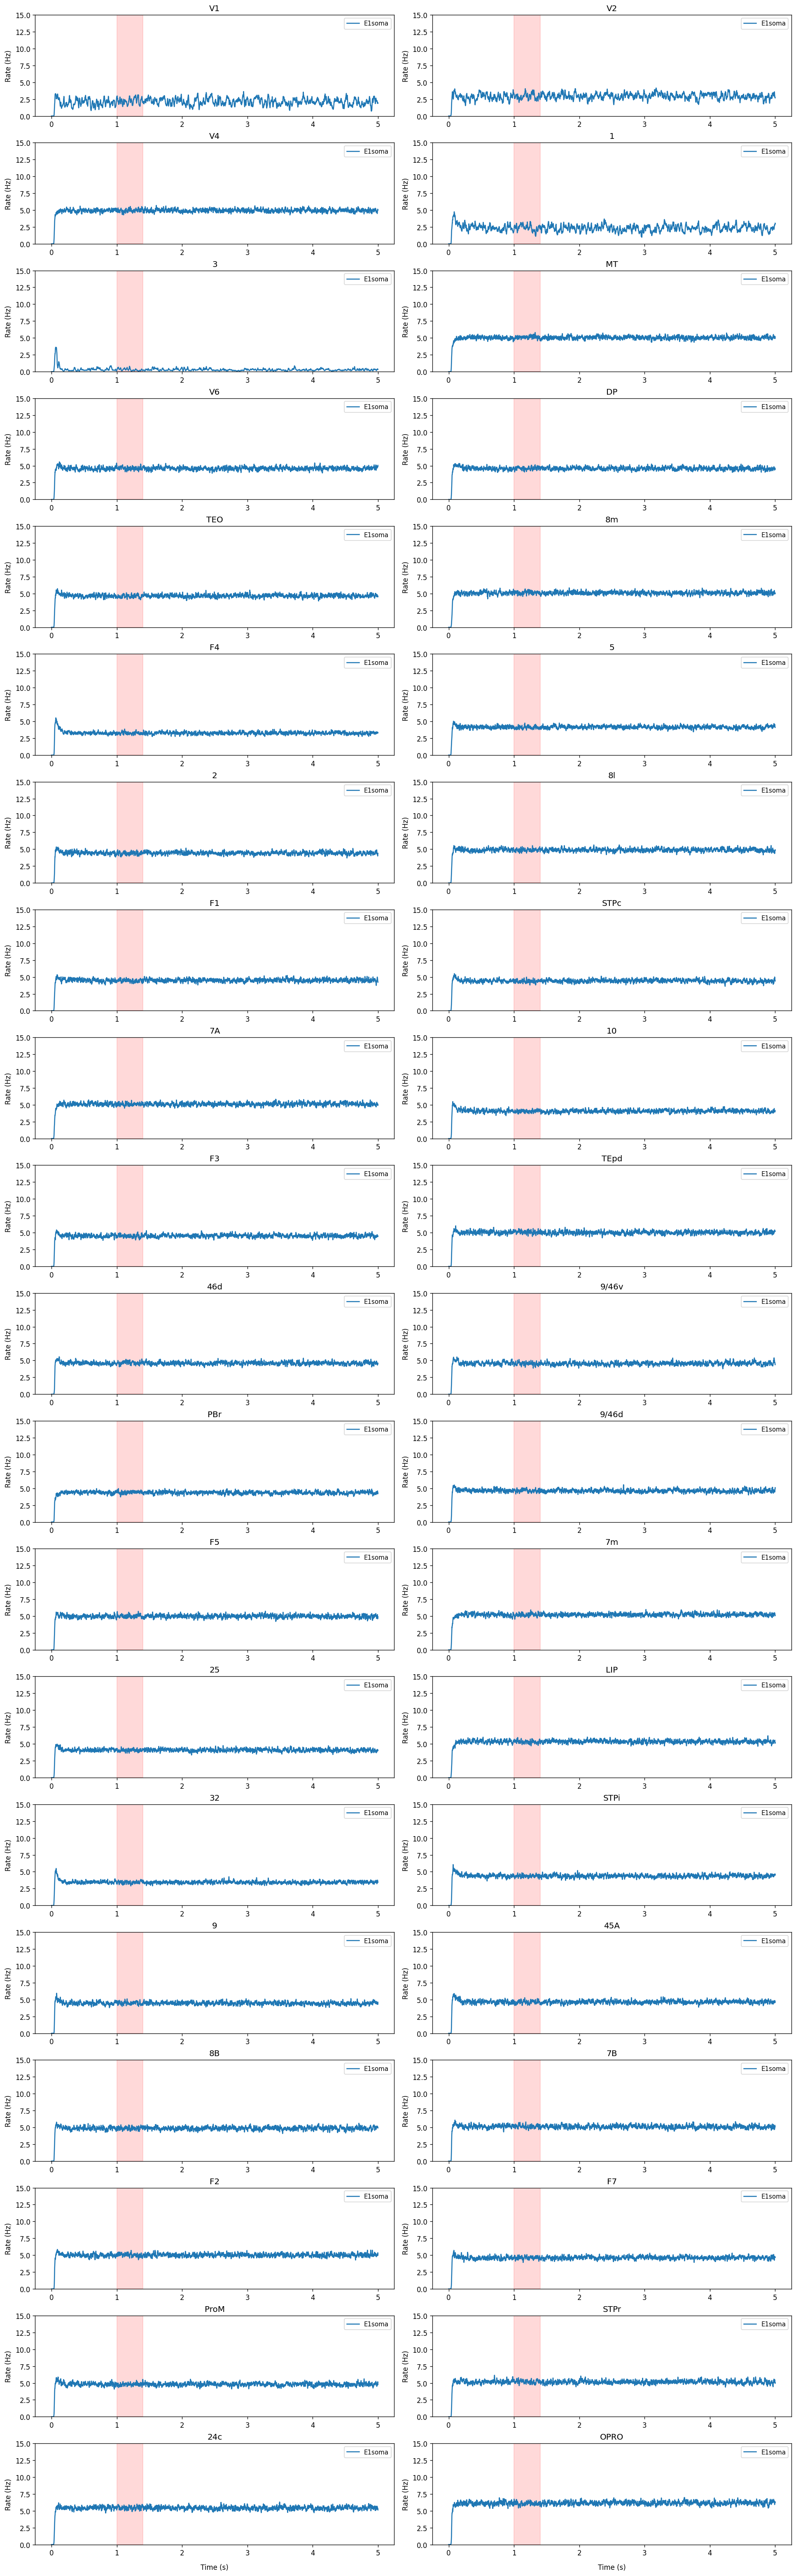

In [32]:
fig, axes = plot_all_areas_2col(
    R=R,
    area_names=area_list_SLN,
    pops=pops,
    # pops_to_show=["E1soma", "SST1"],
    pops_to_show=["E1soma"],
    dt=PARAMS["dt"],
    t_start=0.0,
    t_end=PARAMS["trial_length"],
    stim_on=PARAMS["stim_on"],
    stim_off=PARAMS["stim_off"],
)
plt.show()


In [18]:
print(np.mean(R[:,:,0], axis= 0))

[2.09488469 2.90506653 4.89010004 2.3373713  0.31045701 4.9882422
 4.56163232 4.55577647 4.62365327 5.03550099 3.25850908 4.11447189
 4.39626358 4.84230432 4.47478195 4.39378547 5.05653998 4.05325144
 4.49309539 4.97470501 4.56079589 4.51950655 4.31337003 4.59743962
 4.92962551 5.15903343 4.06012794 5.29202425 3.42200657 4.34618052
 4.42611622 4.61205541 4.82290313 5.06654548 4.97509997 4.5876308
 4.7731901  5.10984613 5.37414953 6.08965024] Hz


--------------------------------- Auto Correlation ------------------------------

In [19]:
# def acf_1d(x, max_lag):
#     x = np.asarray(x, dtype=float)
#     x = x - x.mean()
#     n = x.size
#     if n <= 1:
#         return np.full(max_lag + 1, np.nan)
#
#     c = np.correlate(x, x, mode="full")[n-1:n+max_lag]
#
#     # normalize by (n-lag) to reduce bias at large lags
#     denom = (np.arange(n, n - max_lag - 1, -1)).astype(float)
#     c = c / denom
#
#     # normalize so acf[0]=1
#     if c[0] == 0:
#         return np.full(max_lag + 1, np.nan)
#     return c / c[0]

from statsmodels.tsa.api import acf as sm_acf  # or: from statsmodels.tsa.stattools import acf as sm_acf

def acf_1d(x, max_lag, *, fft=True, missing="none"):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return np.full(max_lag + 1, np.nan)

    # constant / zero-variance => undefined ACF (match your previous behavior)
    if np.allclose(x, x[0]):
        return np.full(max_lag + 1, np.nan)

    # Statsmodels includes lag 0 and returns length nlags+1
    out = sm_acf(
        x,
        nlags=max_lag,
        adjusted=False,   # denom uses (n-k) like your code
        fft=fft,
        missing=missing  # "none" (default). Use "drop"/"conservative" if NaNs exist.
    )

    # (usually unnecessary, but keeps it robust)
    if out.size != max_lag + 1:
        out = np.pad(out, (0, max_lag + 1 - out.size), constant_values=np.nan)

    return out

def plot_acf_oneplot_gradient(
    R, area_names, pops, pop_name="E1soma", *, dt, max_lag_ms=1000,
    cmap_name="viridis", alpha=0.45, lw=1.0, ylim=(-0.2, 1.0),
    add_colorbar=True, show_name_ticks=True
):
    pop_idx = pops.index(pop_name)

    dt_s = float(dt / b2.second) if hasattr(dt, "unit") else float(dt)

    R_np = np.asarray(R)
    rates = R_np[:, :, pop_idx]
    if hasattr(rates, "unit"):
        rates = rates / b2.Hz

    T, A = rates.shape
    max_lag = int(round((max_lag_ms / 1000.0) / dt_s))
    max_lag = min(max_lag, T - 1)
    lags_ms = (np.arange(max_lag + 1) * dt_s) * 1000.0

    acfs = np.zeros((A, max_lag + 1), dtype=float)
    for a in range(A):
        acfs[a] = acf_1d(rates[:, a], max_lag=max_lag)

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=A-1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    for a in range(A):
        ax.plot(lags_ms, acfs[a], color=cmap(norm(a)), alpha=alpha, lw=lw)

    ax.axhline(0, linewidth=0.8)
    ax.set_xlim(0, max_lag_ms)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("ACF (normalized, demeaned)")
    ax.set_title(f"Autocorrelation — all {A} areas (pop: {pop_name})")

    if add_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label("Area index")

        if show_name_ticks and area_names is not None:
            # For 40 areas, show ~8 labeled ticks
            tick_idx = np.linspace(0, A-1, num=8, dtype=int)
            cbar.set_ticks(tick_idx)
            cbar.set_ticklabels([str(area_names[i]) for i in tick_idx])

    fig.tight_layout()
    plt.show()


def bin_firing_rate(
    r, *, dt_ms=5.0, bin_ms=50.0, mode="mean"
):
    """
    Bin/aggregate a firing-rate time series onto coarser bins.

    Parameters
    ----------
    r : array-like
        Firing rate over time. Can be:
          - shape (T,) for a single series
          - shape (T, A) for multiple areas
          - shape (T, A, P) for areas x populations
    dt_ms : float
        Original timestep in milliseconds (e.g., 5.0).
    bin_ms : float
        Desired bin width in milliseconds (e.g., 50.0).
    mode : {"mean", "sum"}
        How to aggregate within each bin:
          - "mean": average rate within the bin (keeps units as Hz)
          - "sum": sum within the bin (not usually meaningful for rates unless you convert to counts)

    Returns
    -------
    r_binned : ndarray
        Binned array with time dimension reduced to T_bin.
    dt_bin_ms : float
        New effective timestep in ms (approximately bin_ms, exact multiple of dt_ms).
    """
    r = np.asarray(r, dtype=float)

    if dt_ms <= 0:
        raise ValueError("dt_ms must be > 0")
    if bin_ms <= 0:
        raise ValueError("bin_ms must be > 0")

    bin_steps = int(round(bin_ms / dt_ms))
    bin_steps = max(1, bin_steps)

    # Actual bin width after rounding to an integer number of steps
    dt_bin_ms = bin_steps * dt_ms

    T = r.shape[0]
    T_use = (T // bin_steps) * bin_steps  # truncate to full bins
    if T_use < bin_steps:
        raise ValueError("Time series too short for the requested bin size.")

    r_trim = r[:T_use]
    new_shape = (T_use // bin_steps, bin_steps) + r.shape[1:]
    r_reshaped = r_trim.reshape(new_shape)

    if mode == "mean":
        r_binned = r_reshaped.mean(axis=1)
    elif mode == "sum":
        r_binned = r_reshaped.sum(axis=1)
    else:
        raise ValueError("mode must be 'mean' or 'sum'")

    return r_binned, dt_bin_ms



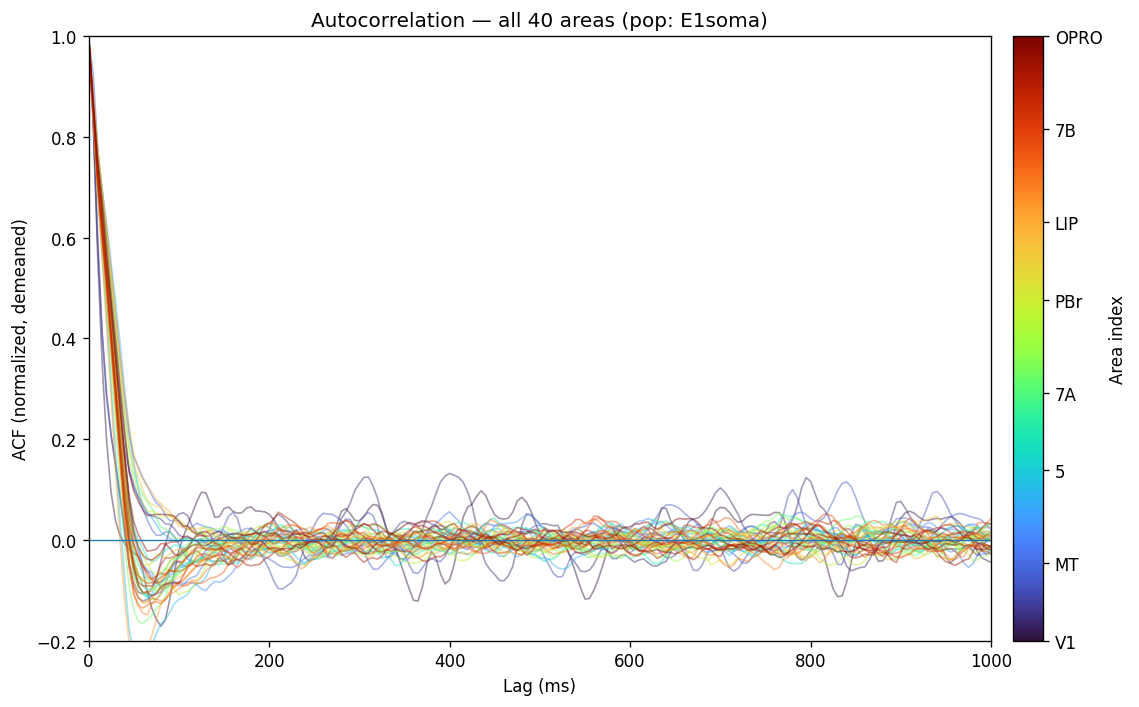

In [20]:
dt_ms = float(PARAMS["dt"] / b2.ms)
bin_ms = 5
R_binned, dt_bin_ms = bin_firing_rate(R[0:,:,:], dt_ms=dt_ms, bin_ms=bin_ms, mode="mean")


# --- call it ---
plot_acf_oneplot_gradient(
    R_binned,
    area_names=area_list_SLN,
    pops=pops,              # use your existing `pops` variable
    pop_name="E1soma",
    dt=bin_ms * brian2.ms,
    max_lag_ms=1000,
    cmap_name="turbo",      # very clear gradient for 40 lines
    alpha=0.45,
    lw=1.0
)

--------------------------------- BOLD
SIGNAL - -----------------------------

In [21]:
def itotal_to_drive_abs(I_total, *, unit=brian2.pA, gain=1.0):
    """
    Translate synaptic currents I_total(t, area, pop) into a per-area neural drive x(t, area).

    You requested:
      drive(t, area) ∝ sum_p | I_total(t, area, p) |

    Parameters
    ----------
    I_total : array-like (T, A, P)
        Brian2 quantity array with units of current (e.g. pA).
    unit : brian2 unit (default: pA)
        Unit used to convert I_total into plain floats. Using pA keeps numbers nicely scaled.
    gain : float
        Scalar mapping from (current in 'unit') to dimensionless drive.

    Returns
    -------
    drive : np.ndarray (T, A), dtype=float
        Dimensionless neural drive suitable as input to a Balloon/BOLD forward model.
    """

    if I_total.ndim != 3:
        raise ValueError(f"I_total must be 3D (T,A,P). Got shape {I_total.shape}")

    # Absolute current, preserve Brian2 units
    I_abs = np.abs(I_total)               # (T, A, P)

    # Sum across populations -> per-area magnitude
    I_area_abs = I_abs.sum(axis=2)        # (T, A), still Brian2 quantity
    print(I_area_abs)
    # Convert to floats in chosen unit, then scale to drive
    drive = gain * (I_area_abs / unit).astype(float)   # (T, A)

    return drive


In [22]:
def balloon_bold_per_area(drive, dt, *, method="rk4", **balloon_params):
    """
    Run the Balloon/BOLD forward model independently for each area.

    Parameters
    ----------
    drive : np.ndarray (T, A)
        Dimensionless neural drive per area.
    dt : float
        Time-step in seconds for integration.
    method : str
        "euler" or "rk4"
    balloon_params : dict
        Parameters passed to balloon_bold (tau, alpha, E0, V0, TE, epsilon, etc.)

    Returns
    -------
    bold : np.ndarray (T, A)
        BOLD signal (ΔS/S0) per area.
    states : list of dict
        Per-area state histories returned by balloon_bold.
    """
    X = np.asarray(drive, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"drive must be 2D (T,A). Got shape {X.shape}")

    T, A = X.shape
    bold = np.zeros((T, A), dtype=float)
    states = []

    for a in range(A):
        b, st = balloon_bold(X[:, a], dt, method=method, **balloon_params)
        bold[:, a] = b
        states.append(st)

    return bold, states

In [23]:

def balloon_bold(
    current,
    dt,
    *,
    kappa=0.65,
    gamma=0.41,
    tau=0.98,
    alpha=0.32,
    E0=0.34,
    V0=0.02,
    TE=0.04,
    epsilon=1.0,
    theta0=40.3,
    r0=25.0,
    neural_gain=1.0,
    method="rk4",
    max_step=0.05,
):
    u = np.asarray(current, dtype=float)
    n = u.size

    # Initial conditions (rest)
    s, f, v, q = 0.0, 1.0, 1.0, 1.0

    x_hist = np.empty(n)
    s_hist = np.empty(n)
    f_hist = np.empty(n)
    v_hist = np.empty(n)
    q_hist = np.empty(n)
    bold = np.empty(n)

    k1 = 4.3 * theta0 * E0 * TE
    k2 = epsilon * r0 * E0 * TE
    k3 = 1.0 - epsilon

    def oxygen_extraction(f_):
        f_safe = max(1e-6, float(f_))
        return 1.0 - (1.0 - E0) ** (1.0 / f_safe)

    def deriv(state, x_):
        s_, f_, v_, q_ = state

        ds = x_ - kappa * s_ - gamma * (f_ - 1.0)
        df = s_

        # Guard v before using fractional power (prevents nan in intermediate RK4 states)
        v_safe = max(1e-6, float(v_))
        v_out = v_safe ** (1.0 / alpha)

        dv = (f_ - v_out) / tau

        E = oxygen_extraction(f_)
        dq = (f_ * (E / E0) - v_out * (q_ / v_safe)) / tau

        return np.array([ds, df, dv, dq], dtype=float)

    def bold_from_vq(v_, q_):
        v_safe = max(1e-6, float(v_))
        return V0 * (k1 * (1.0 - q_) + k2 * (1.0 - q_ / v_safe) + k3 * (1.0 - v_safe))

    # Internal step splitting
    dt = float(dt)
    max_step = float(max_step)
    n_sub = max(1, int(np.ceil(dt / max_step)))
    h = dt / n_sub  # internal step

    def rk4_step(y, x_, h_):
        k_1 = deriv(y, x_)
        k_2 = deriv(y + 0.5 * h_ * k_1, x_)
        k_3 = deriv(y + 0.5 * h_ * k_2, x_)
        k_4 = deriv(y + h_ * k_3, x_)
        return y + (h_ / 6.0) * (k_1 + 2 * k_2 + 2 * k_3 + k_4)

    for t in range(n):
        x = neural_gain * u[t]

        x_hist[t] = x
        s_hist[t] = s
        f_hist[t] = f
        v_hist[t] = v
        q_hist[t] = q
        bold[t] = bold_from_vq(v, q)

        # integrate over dt using substeps
        y = np.array([s, f, v, q], dtype=float)
        for _ in range(n_sub):
            if method.lower() == "euler":
                y = y + h * deriv(y, x)
            elif method.lower() == "rk4":
                y = rk4_step(y, x, h)
            else:
                raise ValueError("method must be 'euler' or 'rk4'")

            # clamp each substep so intermediate states stay physical
            y[1] = max(1e-6, y[1])  # f
            y[2] = max(1e-6, y[2])  # v
            y[3] = max(1e-6, y[3])  # q

        s, f, v, q = y.tolist()

    states = {"x": x_hist, "s": s_hist, "f": f_hist, "v": v_hist, "q": q_hist}
    return bold, states


In [24]:

def downsample_by_block_mean(x, k, *, axis=0):
    """
    Downsample by averaging over non-overlapping blocks of length k.

    Parameters
    ----------
    x : array-like
        Data with time on `axis`. Common shapes: (T, A) or (T, A, P).
    k : int
        Number of original timesteps per new timestep.
    axis : int
        Time axis (default 0).

    Returns
    -------
    y : np.ndarray
        Downsampled array with length floor(T/k) along `axis`.
    """
    x = np.asarray(x)
    if k <= 0:
        raise ValueError("k must be a positive integer.")
    if x.shape[axis] < k:
        raise ValueError(f"Not enough samples along axis {axis} to downsample by k={k}.")

    # Move time axis to front
    x0 = np.moveaxis(x, axis, 0)  # shape (T, ...)
    T = x0.shape[0]
    T2 = T // k  # truncate remainder
    x0 = x0[:T2 * k]

    # Reshape into blocks and average
    new_shape = (T2, k) + x0.shape[1:]
    y0 = x0.reshape(new_shape).mean(axis=1)

    # Move time axis back
    y = np.moveaxis(y0, 0, axis)
    return y


def downsample_to_dt(x, dt_old, dt_new, *, axis=0, require_integer_ratio=True):
    """
    Downsample `x` from dt_old to dt_new by block-mean averaging.

    Parameters
    ----------
    x : array-like
        Data with time on `axis`.
    dt_old : float or Brian2 quantity
        Original timestep.
    dt_new : float or Brian2 quantity
        Desired timestep (must be >= dt_old).
    axis : int
        Time axis (default 0).
    require_integer_ratio : bool
        If True, enforces dt_new/dt_old to be (near) an integer.

    Returns
    -------
    y : np.ndarray
        Downsampled data.
    k : int
        The block size used (number of old steps per new step).
    dt_new_s : float
        New timestep in seconds (float).
    """
    # Convert dt to seconds floats
    dt_old_s = float(dt_old / b2.second) if hasattr(dt_old, "unit") else float(dt_old)
    dt_new_s = float(dt_new / b2.second) if hasattr(dt_new, "unit") else float(dt_new)

    if dt_new_s < dt_old_s:
        raise ValueError(f"dt_new ({dt_new_s}) must be >= dt_old ({dt_old_s}).")

    ratio = dt_new_s / dt_old_s
    k = int(np.round(ratio))

    if require_integer_ratio and not np.isclose(ratio, k, rtol=1e-6, atol=1e-12):
        raise ValueError(
            f"dt_new/dt_old must be an integer for block-mean downsampling. "
            f"Got ratio={ratio} (nearest int {k})."
        )

    y = downsample_by_block_mean(x, k, axis=axis)
    return y, k, dt_new_s


In [25]:

def plot_bold(bold, dt, *, area_names=None, percent=True, max_areas=40):
    """
    Plot BOLD time series.

    bold : (T, A) array
    dt : timestep in seconds
    area_names : list of str, optional
    percent : plot in % signal change if True
    max_areas : limit number of plotted areas (for readability)
    """
    bold = np.asarray(bold)
    T, A = bold.shape
    t = np.arange(T) * dt

    if percent:
        bold_plot = 100 * bold
        ylabel = "BOLD (% ΔS/S₀)"
    else:
        bold_plot = bold
        ylabel = "BOLD (ΔS/S₀)"

    if area_names is None:
        area_names = [f"Area {i}" for i in range(A)]

    plt.figure(figsize=(10, 4))
    for a in range(min(A, max_areas)):
        plt.plot(t, bold_plot[:, a], label=area_names[a])

    plt.xlabel("Time (s)")
    plt.ylabel(ylabel)
    plt.title("BOLD signal per area")
    # plt.legend()
    plt.tight_layout()
    plt.show()


In [26]:
def seed_based_fc(bold, seed_idx):
    seed = bold[:, seed_idx]
    return np.array([
        np.corrcoef(seed, bold[:, a])[0, 1]
        for a in range(bold.shape[1])
    ])


In [27]:
import pandas as pd

def save_bold_csv(bold, dt, filename, *, area_names=None, percent=True):
    """
    Save BOLD time series to CSV.

    bold : (T, A) array
    dt : timestep in seconds
    filename : output CSV file
    area_names : list of str, optional
    percent : save in % signal change if True
    """
    bold = np.asarray(bold)
    T, A = bold.shape
    time = np.arange(T) * dt

    if percent:
        bold_out = 100 * bold
        unit = "%_BOLD"
    else:
        bold_out = bold
        unit = "BOLD"

    if area_names is None:
        area_names = [f"area_{i}" for i in range(A)]

    data = {"time_s": time}
    for a in range(A):
        data[f"{area_names[a]}_{unit}"] = bold_out[:, a]

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)


In [28]:
def drive_abs_to_balloon_input(
    drive_abs,
    *,
    baseline_idx,     # (i0, i1) indices defining baseline window
    gain=1.0,
    clamp_nonnegative=False,
    per_area=True
):
    """
    Convert a strictly-positive absolute drive into a baseline-referenced Balloon input x(t).

    x(t) = gain * (drive_abs(t) - drive0)

    Parameters
    ----------
    drive_abs : array (T, A) or (T,)
    baseline_idx : tuple(int,int)
        Baseline window indices (i0,i1)
    gain : float
        Scaling into Balloon's x units
    clamp_nonnegative : bool
        If True, x = max(0, x). (Not recommended for FC; use only if you insist on purely excitatory coupling.)
    per_area : bool
        If True, compute drive0 separately for each area. If False, use a single scalar baseline.

    Returns
    -------
    x : np.ndarray same shape as drive_abs
        Baseline-referenced Balloon input.
    drive0 : baseline level (A,) or scalar
    """
    d = np.asarray(drive_abs, dtype=float)
    i0, i1 = baseline_idx
    if d.ndim == 1:
        d0 = d[i0:i1].mean()
        x = gain * (d - d0)
        if clamp_nonnegative:
            x = np.maximum(0.0, x)
        return x, d0

    # d is (T, A)
    if per_area:
        d0 = d[i0:i1, :].mean(axis=0, keepdims=True)  # (1, A)
        x = gain * (d - d0)
        if clamp_nonnegative:
            x = np.maximum(0.0, x)
        return x, d0.squeeze()
    else:
        d0 = d[i0:i1, :].mean()  # scalar
        x = gain * (d - d0)
        if clamp_nonnegative:
            x = np.maximum(0.0, x)
        return x, d0


In [29]:
dt_old = PARAMS["dt"]
dt_balloon = 1000 * brian2.ms
drive = itotal_to_drive_abs(I_total_abs[10000:,:,:], unit=brian2.pA, gain=1)   # (T, A)
drive_ds, k, dt_balloon_s = downsample_to_dt(drive, dt_old, dt_balloon)

# choose baseline window (example: first 10 seconds)
i0 = int(0/dt_balloon_s)
# i1 = int(PARAMS["trial_length"] / dt_balloon_s)
i1 = int(55 / dt_balloon_s)

x, drive0 = drive_abs_to_balloon_input(drive_ds, baseline_idx=(i0, i1), gain=0.075)

bold, states = balloon_bold_per_area(
    x,
    dt=dt_balloon_s,
    TE=0.04,
    method="rk4"
)

bold_percent = 100 * bold

[] A


ValueError: Not enough samples along axis 0 to downsample by k=2000.

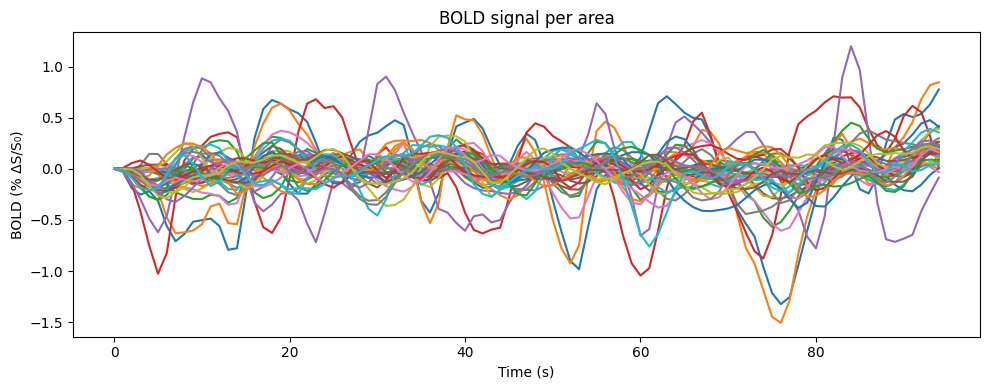

In [182]:
plot_bold(bold, dt_balloon_s)
save_bold_csv(
    bold,
    dt=dt_balloon_s,
    filename = "bold_per_area.csv"
)


In [183]:
seed_based = seed_based_fc(bold, 28)
print(seed_based)

[-0.14234199 -0.00462405  0.05258793  0.2212375  -0.17132544 -0.07281051
 -0.09003469  0.11104439  0.01135713  0.05692281  0.18718126  0.04918612
  0.14159493  0.25667332  0.21797734  0.26127131 -0.23502603  0.65708664
  0.06723018  0.22952747  0.00769294  0.00578775 -0.08405641 -0.17608592
  0.37566732 -0.03193447  0.7760845  -0.15816462  1.          0.55031999
  0.51256702 -0.00427486  0.03038263  0.24031621  0.13021344  0.18676548
  0.30526771  0.49134542  0.41075929  0.4290735 ]


In [161]:
print(drive_ds)

tempdf = pd.DataFrame(drive_ds)
tempdf.to_csv("drive.csv", index=False)

[[1269.51653173 1302.08792084 1410.02689206 ... 1729.44273593
  1741.21501255 1806.36359527]
 [1275.1157713  1306.56766881 1410.82836423 ... 1729.39951487
  1740.32537403 1804.12415222]
 [1270.72634301 1302.67928534 1409.67119158 ... 1729.37796895
  1741.57614346 1805.24104364]
 ...
 [1276.70739558 1305.56642351 1410.96888583 ... 1730.60761435
  1742.24389897 1806.32325327]
 [1272.48880442 1303.85675274 1409.80549558 ... 1729.43582599
  1742.00032207 1806.68414721]
 [1272.26871524 1304.749669   1410.00922705 ... 1728.97873332
  1740.47744966 1805.60662604]]


In [162]:
# ===========================
# PARAMETER SWEEP (PARALLEL)
# Paste this whole block into one notebook cell.
# Assumes you already have these functions defined elsewhere in your notebook:
#   - load_anatomy
#   - prepare_connectivity
#   - initialise_variables
#   - large_scale_da_model
#   - plot_all_areas_2col
#   - bin_firing_rate
# ===========================

import os



# -------------------------
# ACF plot helper that RETURNS a fig (saveable)
# -------------------------
def plot_acf_oneplot_gradient_fig(
    R, area_names, pops, pop_name="E1soma", *, dt, max_lag_ms=1000,
    cmap_name="viridis", alpha=0.45, lw=1.0, ylim=(-0.2, 1.0),
    add_colorbar=True, show_name_ticks=True
):
    from statsmodels.tsa.api import acf as sm_acf

    def acf_1d(x, max_lag, *, fft=True, missing="none"):
        x = np.asarray(x, dtype=float)
        n = x.size
        if n <= 1 or np.allclose(x, x[0]):
            return np.full(max_lag + 1, np.nan)
        out = sm_acf(x, nlags=max_lag, adjusted=False, fft=fft, missing=missing)
        if out.size != max_lag + 1:
            out = np.pad(out, (0, max_lag + 1 - out.size), constant_values=np.nan)
        return out

    pop_idx = pops.index(pop_name)

    dt_s = float(dt / b2.second) if hasattr(dt, "unit") else float(dt)
    R_np = np.asarray(R)

    rates = R_np[:, :, pop_idx]
    if hasattr(rates, "unit"):
        rates = rates / b2.Hz

    T, A = rates.shape
    max_lag = int(round((max_lag_ms / 1000.0) / dt_s))
    max_lag = min(max_lag, T - 1)
    lags_ms = (np.arange(max_lag + 1) * dt_s) * 1000.0

    acfs = np.zeros((A, max_lag + 1), dtype=float)
    for a in range(A):
        acfs[a] = acf_1d(rates[:, a], max_lag=max_lag)

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=A - 1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    for a in range(A):
        ax.plot(lags_ms, acfs[a], color=cmap(norm(a)), alpha=alpha, lw=lw)

    ax.axhline(0, linewidth=0.8)
    ax.set_xlim(0, max_lag_ms)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("ACF (normalized, demeaned)")
    ax.set_title(f"Autocorrelation — all {A} areas (pop: {pop_name})")

    if add_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label("Area index")

        if show_name_ticks and area_names is not None:
            tick_idx = np.linspace(0, A - 1, num=8, dtype=int)
            cbar.set_ticks(tick_idx)
            cbar.set_ticklabels([str(area_names[i]) for i in tick_idx])

    fig.tight_layout()
    return fig, ax, acfs, lags_ms


# -------------------------
# Sweep utilities
# -------------------------
def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def _sanitize(s: str) -> str:
    return (
        str(s)
        .replace(" ", "")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace("|", "_")
        .replace("*", "x")
        .replace("<", "")
        .replace(">", "")
        .replace("?", "")
        .replace('"', "")
    )

def _fmt_value(v) -> str:
    return _sanitize(v)

def _make_run_folder_name(run_idx: int, swept_items):
    parts = [f"{k}={_fmt_value(v)}" for k, v in swept_items]
    name = f"run_{run_idx:04d}__" + "__".join(parts)
    return name[:180]  # guard path length

def _range_inclusive(vmin, vmax, step):
    if step == 0:
        raise ValueError("Step size cannot be 0.")

    vals = []
    v = vmin

    # Works for floats and Brian2 quantities
    if step > 0:
        while v <= vmax + (step * 1e-12):
            vals.append(v)
            v = v + step
    else:
        while v >= vmax + (step * 1e-12):
            vals.append(v)
            v = v + step

    return vals

def _params_to_jsonable(d: dict) -> dict:
    out = {}
    for k, v in d.items():
        try:
            json.dumps(v)
            out[k] = v
        except TypeError:
            out[k] = str(v)
    return out


# -------------------------
# Worker (runs in separate process)
# -------------------------
def _sweep_worker(
    run_idx: int,
    total_runs: int,
    names: list[str],
    combo: tuple,
    PARAMS_base: dict,
    out_dir: Path,
    pops_to_show: tuple[str, ...],
    acf_pop_name: str,
    acf_skip_steps: int,
    acf_bin_ms: int,
    acf_max_lag_ms: int,
    verbose: bool,
    seed_base: int | None,
):
    # Per-run reproducibility (optional)
    if seed_base is not None:
        np.random.seed(seed_base + run_idx)

    # Brian2: reset scope (safe even if you aren't creating Brian2 objects)
    try:
        b2.start_scope()
    except Exception:
        pass

    # Matplotlib: ensure non-interactive backend in workers
    try:
        plt.switch_backend("Agg")
    except Exception:
        pass

    params_run = copy.deepcopy(PARAMS_base)
    swept_items = list(zip(names, combo))
    for k, v in swept_items:
        params_run[k] = v

    run_folder_name = _make_run_folder_name(run_idx, swept_items)
    run_dir = _ensure_dir(out_dir / run_folder_name)

    if verbose:
        pretty = ", ".join([f"{k}={v}" for k, v in swept_items])
        print(f"[{run_idx}/{total_runs}] {pretty}")

    # Load anatomy inside worker (robust for multiprocessing + notebooks)
    (sln, fln, hierarchy, area_list_SLN,
     df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy()

    # Keep compatibility with your existing notebook functions that expect globals
    globals()["area_list_SLN"] = area_list_SLN

    # Connectivity
    (pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac,
     J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets,
     nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad, g_m, lr_targets_FEF) = prepare_connectivity(
        params_run, spine_count_raw, fln, sln, d1_density_raw
    )
    globals()["pops"] = pops

    # State init
    (num_iterations, R, s_nmda, s_ampa, s_gaba, s_gaba_dend, s_adapt, I_ext,
     I_lr_nmda, I_lr_ampa, I_local_nmda, I_local_ampa, I_local_gaba, I_soma_dend,
     I_total, I_exc_dend, I_inh_dend, I_local_gaba_dend, I_adapt, I_0,
     I_noise, noise_rhs, I_total_abs) = initialise_variables(
        params_run, num_areas, num_pops, num_e_pops, area_list_SLN
    )

    # Run model
    R = large_scale_da_model(
        pops, num_pops, num_e_pops, num_areas, e_grad, g_adapt, ampa_frac, nmda_frac,
        J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets,
        nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad, num_iterations, R, s_nmda,
        s_ampa, s_gaba, s_gaba_dend, s_adapt,
        I_ext, I_lr_nmda, I_lr_ampa, I_local_nmda, I_local_ampa, I_local_gaba,
        I_soma_dend, I_total, I_exc_dend, I_inh_dend, I_local_gaba_dend, I_adapt,
        I_0, I_noise, noise_rhs, params_run, lr_targets_FEF, I_total_abs
    )

    # Save firing-rate plot
    fig_fr, _ = plot_all_areas_2col(
        R=R,
        area_names=area_list_SLN,
        pops=pops,
        pops_to_show=list(pops_to_show),
        dt=params_run["dt"],
        t_start=0.0,
        t_end=params_run["trial_length"],
        stim_on=params_run.get("stim_on", None),
        stim_off=params_run.get("stim_off", None),
    )
    fig_fr.savefig(run_dir / "firing_rates.png", dpi=200, bbox_inches="tight")
    plt.close(fig_fr)

    # Save ACF plot (bin then ACF)
    dt_ms = float(params_run["dt"] / b2.ms)
    R_binned, _ = bin_firing_rate(
        R[acf_skip_steps:, :, :],
        dt_ms=dt_ms,
        bin_ms=acf_bin_ms,
        mode="mean",
    )

    fig_acf, _, _acfs, _lags_ms = plot_acf_oneplot_gradient_fig(
        R_binned,
        area_names=area_list_SLN,
        pops=pops,
        pop_name=acf_pop_name,
        dt=acf_bin_ms * b2.ms,
        max_lag_ms=acf_max_lag_ms,
        cmap_name="turbo",
        alpha=0.45,
        lw=1.0,
    )
    fig_acf.savefig(run_dir / "acf.png", dpi=200, bbox_inches="tight")
    plt.close(fig_acf)

    # Save full params snapshot for this run
    (run_dir / "params.json").write_text(json.dumps(_params_to_jsonable(params_run), indent=2))

    # Return record for parent process to write aggregate files safely
    return {
        "run_idx": run_idx,
        "run_folder": run_folder_name,
        "swept": {k: str(v) for k, v in swept_items},
        "params_full": _params_to_jsonable(params_run),
    }


# -------------------------
# Main sweep runner (parallel by default)
# -------------------------
def run_parameter_sweep(
    *,
    PARAMS: dict,
    sweep_specs: list[tuple[str, object, object, object]],  # [(name, min, max, step), ...]
    out_dir: str | Path,
    pops_to_show=("E1soma",),
    acf_pop_name="E1soma",
    acf_skip_steps=6000,
    acf_bin_ms=5,
    acf_max_lag_ms=750,
    overwrite=False,
    verbose=True,
    # parallel controls
    parallel: bool = True,
    n_jobs: int = -1,                 # -1 = all cores
    backend: str = "loky",            # best for notebooks
    batch_size: int | str = "auto",
    joblib_verbose: int = 10,
    seed_base: int | None = None,     # e.g. 1234 for reproducibility
):
    out_dir = Path(out_dir)

    if out_dir.exists():
        if overwrite:
            shutil.rmtree(out_dir)
        elif any(out_dir.iterdir()):
            raise FileExistsError(
                f"Output directory '{out_dir}' exists and is not empty. "
                f"Set overwrite=True or choose a new folder."
            )
    _ensure_dir(out_dir)

    names = [s[0] for s in sweep_specs]
    grids = []
    for (name, vmin, vmax, step) in sweep_specs:
        vals = _range_inclusive(vmin, vmax, step)
        if len(vals) == 0:
            raise ValueError(f"Sweep '{name}' produced 0 values. Check min/max/step.")
        grids.append(vals)

    total_runs = int(np.prod([len(g) for g in grids]))

    # Save sweep spec once
    sweep_spec_payload = [
        {"name": n, "min": str(vmin), "max": str(vmax), "step": str(step)}
        for (n, vmin, vmax, step) in sweep_specs
    ]
    (out_dir / "sweep_spec.json").write_text(json.dumps(sweep_spec_payload, indent=2))

    # Build iterable of (run_idx, combo) without storing huge lists
    combo_iter = itertools.product(*grids)

    def job_iter():
        for run_idx, combo in enumerate(combo_iter, start=1):
            yield delayed(_sweep_worker)(
                run_idx=run_idx,
                total_runs=total_runs,
                names=names,
                combo=combo,
                PARAMS_base=PARAMS,
                out_dir=out_dir,
                pops_to_show=tuple(pops_to_show),
                acf_pop_name=acf_pop_name,
                acf_skip_steps=acf_skip_steps,
                acf_bin_ms=acf_bin_ms,
                acf_max_lag_ms=acf_max_lag_ms,
                verbose=verbose,
                seed_base=seed_base,
            )

    if parallel:
        results = Parallel(
            n_jobs=n_jobs,
            backend=backend,
            batch_size=batch_size,
            verbose=joblib_verbose,
        )(job_iter())
    else:
        results = [j() for j in job_iter()]

    # Aggregate outputs written once (no race conditions)
    jsonl_path = out_dir / "all_params.jsonl"
    csv_path = out_dir / "all_params_swept.csv"

    with open(csv_path, "w", encoding="utf-8") as f:
        f.write("run_idx,run_folder," + ",".join(names) + "\n")

    # Joblib preserves order, but keep this for safety
    results.sort(key=lambda r: r["run_idx"])

    with open(jsonl_path, "w", encoding="utf-8") as f_jsonl, open(csv_path, "a", encoding="utf-8") as f_csv:
        for r in results:
            f_jsonl.write(json.dumps({"run_idx": r["run_idx"], "run_folder": r["run_folder"], **r["params_full"]}) + "\n")
            row = [str(r["run_idx"]), r["run_folder"]] + [r["swept"][k] for k in names]
            f_csv.write(",".join(row) + "\n")

    if verbose:
        print(f"Done. Results in: {out_dir.resolve()}")
        print(f"  - all params: {jsonl_path.name}")
        print(f"  - swept table: {csv_path.name}")
        print(f"  - per-run plots: */firing_rates.png and */acf.png")

In [163]:
# sweep_specs = [
#     # ("mu_ee", 1.5, 2.4, 0.05),
#     # ("mu_ie",      0.7, 2.5, 0.1),
#     # ("std_noise", 1 * brian2.pA, 4.5 * brian2.pA, 0.5 * brian2.pA)
#     ("I_background_e", 50 * brian2.pA, 620 * brian2.pA, 15 * brian2.pA),
#     ("I_background_i", 50 * brian2.pA, 620 * brian2.pA, 15 * brian2.pA)
#
# ]
#
# run_parameter_sweep(
#     PARAMS=PARAMS,
#     sweep_specs=sweep_specs,
#     out_dir="sweeps/background",
#     parallel=True,
#     n_jobs= -1,
#     backend="loky",
#     seed_base=1234,
#     overwrite=True
# )